### Imports

In [1]:
import os
from pathlib import Path
from torchvision import transforms
import cv2
from tqdm import tqdm
import numpy as np
from transformers import AutoImageProcessor, AutoModelForImageClassification
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import matplotlib.pyplot as plt


### Load kedro

In [2]:
os.chdir("../../")

%load_ext kedro.ipython

[05/04/26 13:07:46] INFO     Using                                                                  ]8;id=703911;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\framework\project\__init__.py\__init__.py]8;;\:]8;id=392093;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\framework\project\__init__.py#269\269]8;;\
                             'c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-pac                
                             kages\kedro\framework\project\rich_logging.yml' as logging                            
                             configuration.                                                                        

[05/04/26 13:07:47] INFO     Registered line magic '%reload_kedro'                                   ]8;id=348332;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=251140;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py#64\64]8;;\

                    INFO     Registered line magic '%load_node'                                      ]8;id=743298;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=221019;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py#66\66]8;;\

                    INFO     Resolved project path as:                                              ]8;id=136777;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=256965;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py#181\181]8;;\
                             c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\cxr-training-pipeli                
                             ne.                                                                                   
                             To set a different path, run '%reload_kedro <project_root>'                           

[05/04/26 13:07:53] WARNING  c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-pack ]8;id=699599;file://C:\Python312\Lib\warnings.py\warnings.py]8;;\:]8;id=833368;file://C:\Python312\Lib\warnings.py#112\112]8;;\
                             ages\requests\__init__.py:113: RequestsDependencyWarning: urllib3                     
                             (2.6.3) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't                   
                             match a supported version!                                                            
                               warnings.warn(                                                                      
                                                                                                                   

...

                    WARNING  c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-pack ]8;id=80038;file://C:\Python312\Lib\warnings.py\warnings.py]8;;\:]8;id=547381;file://C:\Python312\Lib\warnings.py#112\112]8;;\
                             ages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning:                   
                             The filesystem tracking backend (e.g., './mlruns') is deprecated as of                
                             February 2026. Consider transitioning to a database backend (e.g.,                    
                             'sqlite:///mlflow.db') to take advantage of the latest MLflow                         
                             features. See                                                                         
                             https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store                   
                             for migration guidance.                                                               
                               return FileStore(store_uri, store_uri)                                              
                                                                                                                   

[05/04/26 13:08:12] INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=449007;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro_telemetry\plugin.py\plugin.py]8;;\:]8;id=648035;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro_telemetry\plugin.py#242\242]8;;\
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/about/telemetry/                                     

[05/04/26 13:08:13] INFO     Kedro project cxr-training-pipeline                                    ]8;id=893292;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=369963;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py#147\147]8;;\

                    INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=580251;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=758387;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py#148\148]8;;\
                             'pipelines'                                                                           

                    INFO     Registered line magic 'run_viz'                                        ]8;id=255777;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=818021;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py#154\154]8;;\

### Huggingface snippet
This part of code is directly copied from : "https://huggingface.co/google/vit-base-patch16-224"

In [3]:
from transformers import ViTImageProcessor, ViTForImageClassification
from PIL import Image
import requests

url = 'http://images.cocodataset.org/val2017/000000039769.jpg'
image = Image.open(requests.get(url, stream=True).raw)

processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224')
model = ViTForImageClassification.from_pretrained('google/vit-base-patch16-224')

inputs = processor(images=image, return_tensors="pt")
outputs = model(**inputs)
logits = outputs.logits
# model predicts one of the 1000 ImageNet classes
predicted_class_idx = logits.argmax(-1).item()
print("Predicted class:", model.config.id2label[predicted_class_idx])


[05/04/26 13:08:18] WARNING  Warning: You are sending unauthenticated requests to the HF Hub. Please   ]8;id=622880;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\huggingface_hub\utils\_http.py\_http.py]8;;\:]8;id=571713;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\huggingface_hub\utils\_http.py#916\916]8;;\
                             set a HF_TOKEN to enable higher rate limits and faster downloads.                     

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Predicted class: Egyptian cat


### Testing model on RTG image

In [4]:
image_path = Path("data/01_raw/images/00000001_000.png")

In [5]:
image_rtg = Image.open(image_path).convert("RGB")

inputs = processor(images=image_rtg, return_tensors="pt")
outputs = model(**inputs)
logits = outputs.logits
# model predicts one of the 1000 ImageNet classes
predicted_class_idx = logits.argmax(-1).item()
print("Predicted class:", model.config.id2label[predicted_class_idx])


Predicted class: nematode, nematode worm, roundworm


### ViT for medical images - huggingface snippet
This part of code is driectly cpied from : "https://huggingface.co/codewithdark/vit-chest-xray"

In [6]:
from transformers import AutoImageProcessor, AutoModelForImageClassification
import torch

processor = AutoImageProcessor.from_pretrained("codewithdark/vit-chest-xray")
model = AutoModelForImageClassification.from_pretrained("codewithdark/vit-chest-xray")

# Define label columns (class names)
label_columns = ['Cardiomegaly', 'Edema', 'Consolidation', 'Pneumonia', 'No Finding']

# Open the image
image = Image.open(image_path)

# Ensure the image is in RGB mode (required by most image classification models)
if image.mode != 'RGB':
    image = image.convert('RGB')
    print("Image converted to RGB.")

# Step 2: Preprocess the image using the processor
inputs = processor(images=image, return_tensors="pt")

# Step 3: Make a prediction (using the model)
with torch.no_grad():  # Disable gradient computation during inference
    outputs = model(**inputs)

# Step 4: Extract logits and get the predicted class index
logits = outputs.logits  # Raw logits from the model
predicted_class_idx = torch.argmax(logits, dim=-1).item()  # Get the class index

# Step 5: Map the predicted index to a class label
# You can also use `model.config.id2label`, but we'll use `label_columns` for this task
predicted_class_label = label_columns[predicted_class_idx]

# Output the results
print(f"Predicted Class Index: {predicted_class_idx}")
print(f"Predicted Class Label: {predicted_class_label}")

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Image converted to RGB.
Predicted Class Index: 0
Predicted Class Label: Cardiomegaly


### Testing XAI on VIT

In [7]:
class ViTWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        return self.model(pixel_values=x).logits

def reshape_transform(tensor):
    # tensor: [batch, tokens, channels]
    # remove CLS token
    tensor = tensor[:, 1:, :]

    # ViT base usually has 14x14 patches for 224x224 input
    h = w = int(tensor.shape[1] ** 0.5)

    tensor = tensor.reshape(tensor.size(0), h, w, tensor.size(2))
    tensor = tensor.permute(0, 3, 1, 2)
    return tensor

In [8]:
def get_vit_visualization(model: AutoModelForImageClassification, processor: AutoImageProcessor, image_path: str, target_layers: list, targets: list) -> tuple:
    image = Image.open(image_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt")
    input_tensor = inputs["pixel_values"]


    cam = GradCAM(
        model=model,
        target_layers=target_layers,
        reshape_transform=reshape_transform
    )

    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

    img_float = np.array(image.resize((input_tensor.shape[-1], input_tensor.shape[-2]))).astype(np.float32) / 255.0

    visualization = show_cam_on_image(img_float, grayscale_cam, use_rgb=True)

    output_image = Image.fromarray(visualization)
    return image, output_image

In [9]:
def plot_image_with_gradcam(original_image, gradcam_image):
    fig, ax = plt.subplots(1, 2, figsize=(20, 10))
    ax[0].imshow(original_image)
    ax[0].set_title("Original Image")
    ax[0].axis("off")
    ax[1].imshow(gradcam_image)
    ax[1].set_title("Grad-CAM Visualization")
    ax[1].axis("off")
    plt.show()

In [10]:
model_name = "codewithdark/vit-chest-xray"
processor = AutoImageProcessor.from_pretrained(model_name)
hf_model = AutoModelForImageClassification.from_pretrained(model_name)
hf_model.eval()

model = ViTWrapper(hf_model)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

In [11]:
image_path = Path("data/01_raw/images/00000001_000.png")

target_layers = [hf_model.vit.encoder.layer[-1].layernorm_before]
targets = [ClassifierOutputTarget(0)] # Cardiomegaly

image, output_image = get_vit_visualization(model, processor, image_path, target_layers, targets)


Generating Grad-CAM for Cardiomegaly...


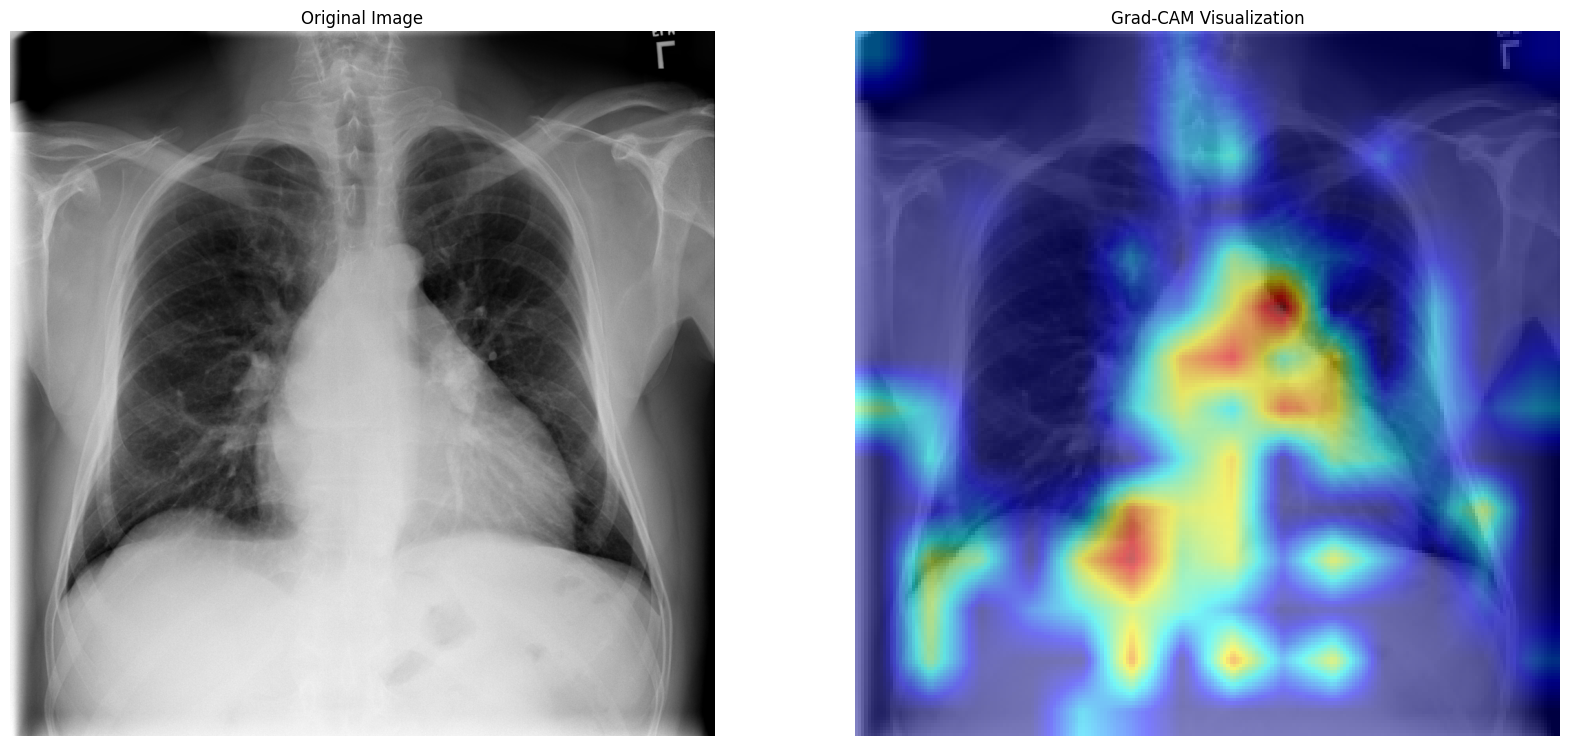

Generating Grad-CAM for Edema...


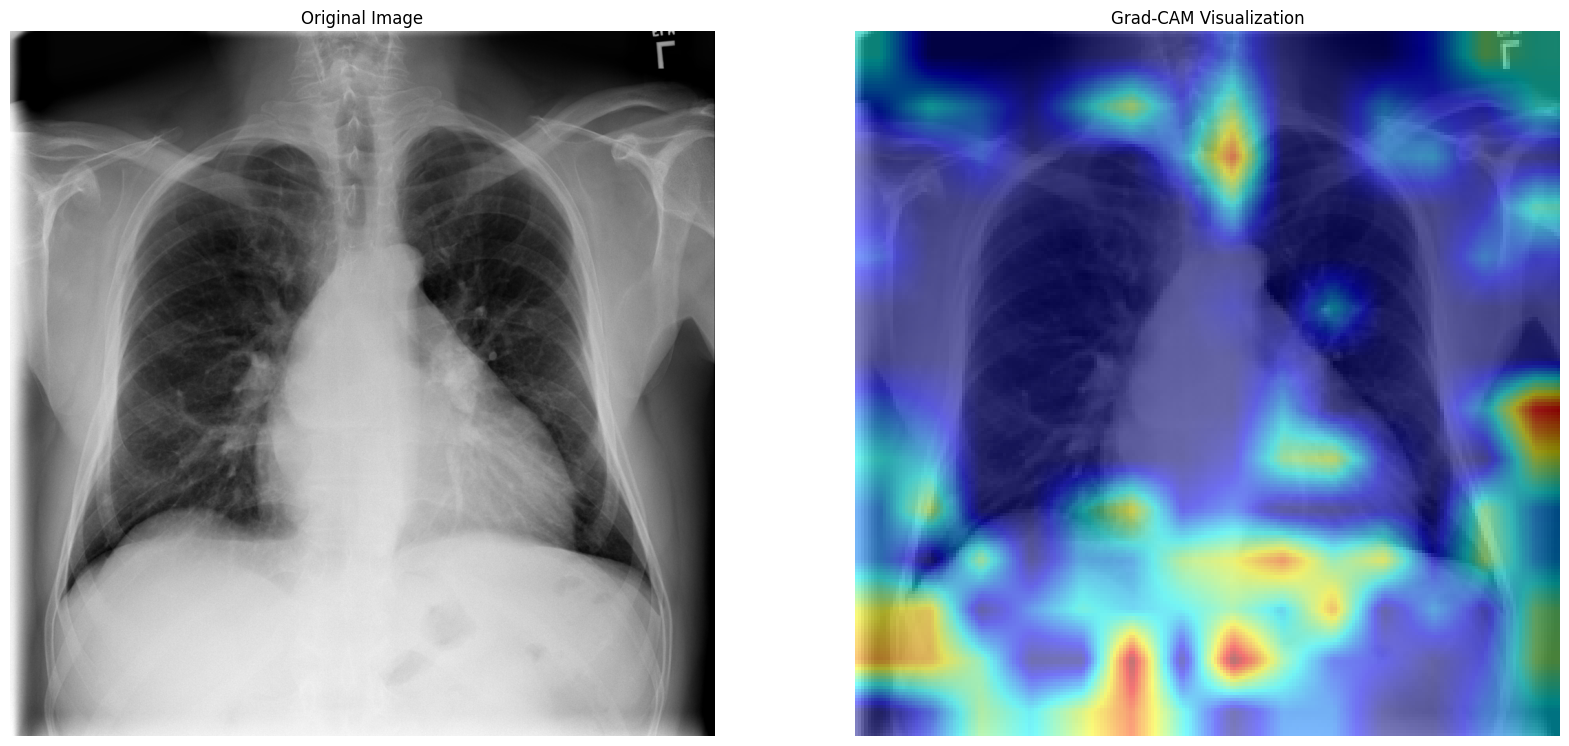

Generating Grad-CAM for Consolidation...


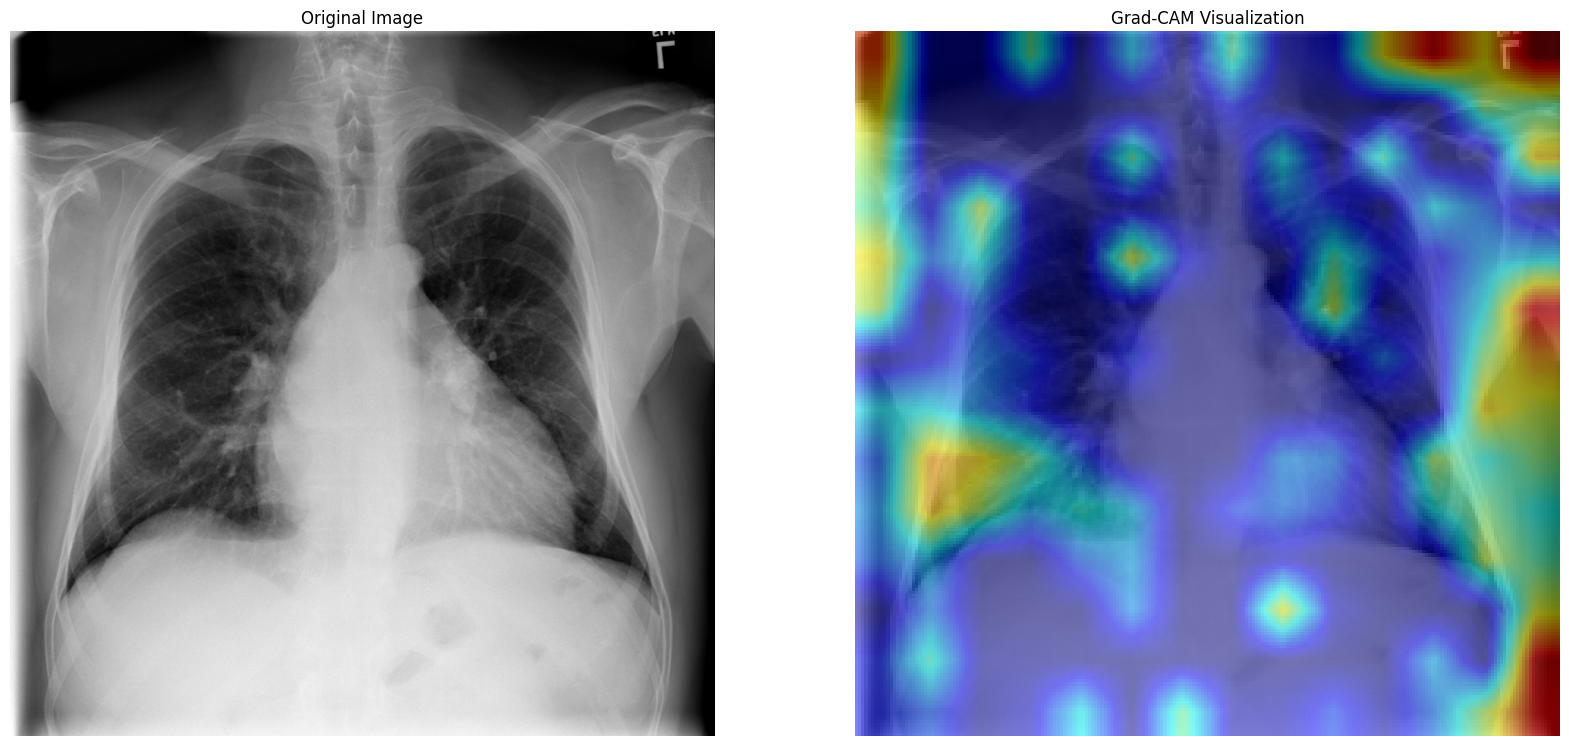

Generating Grad-CAM for Pneumonia...


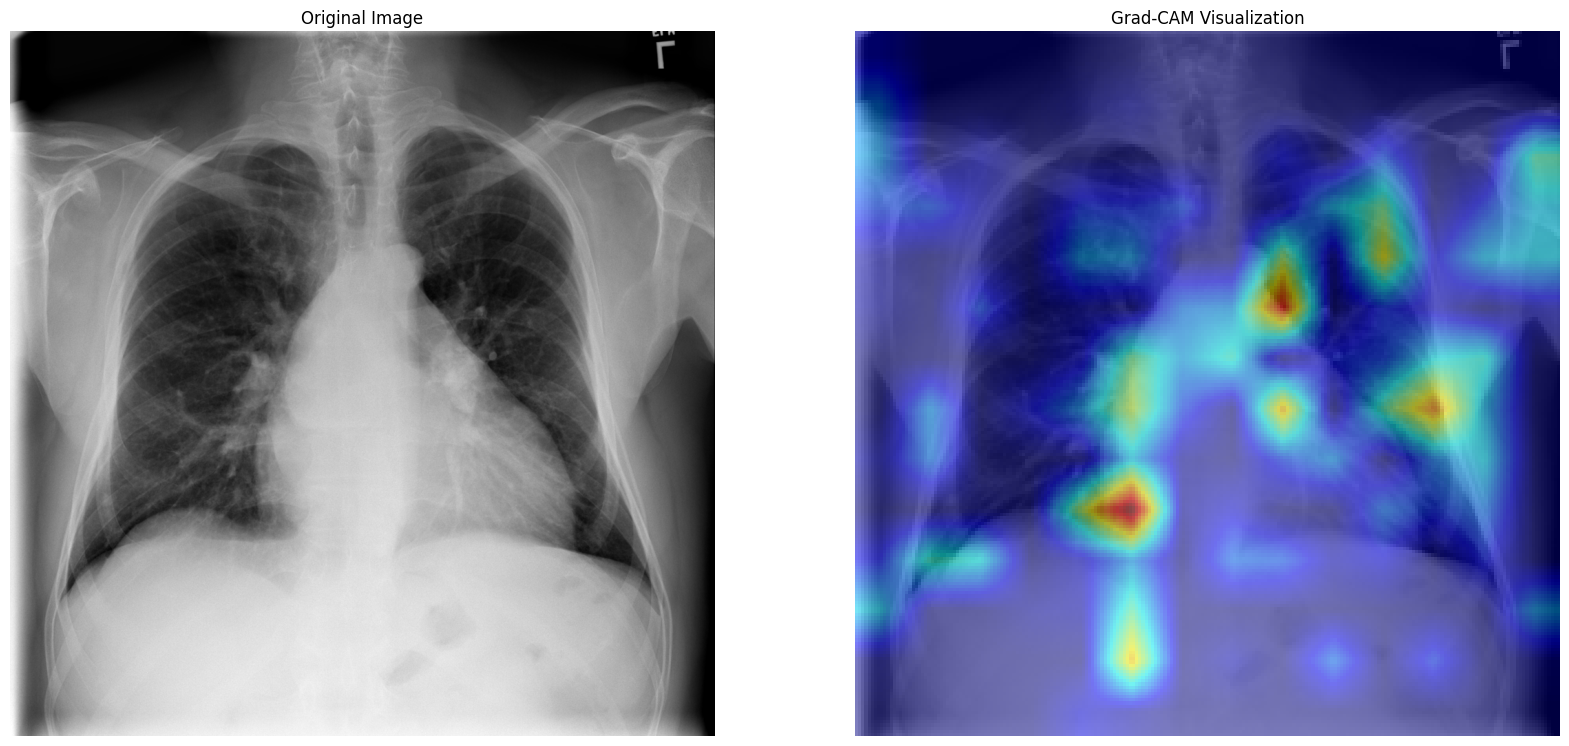

Generating Grad-CAM for No Finding...


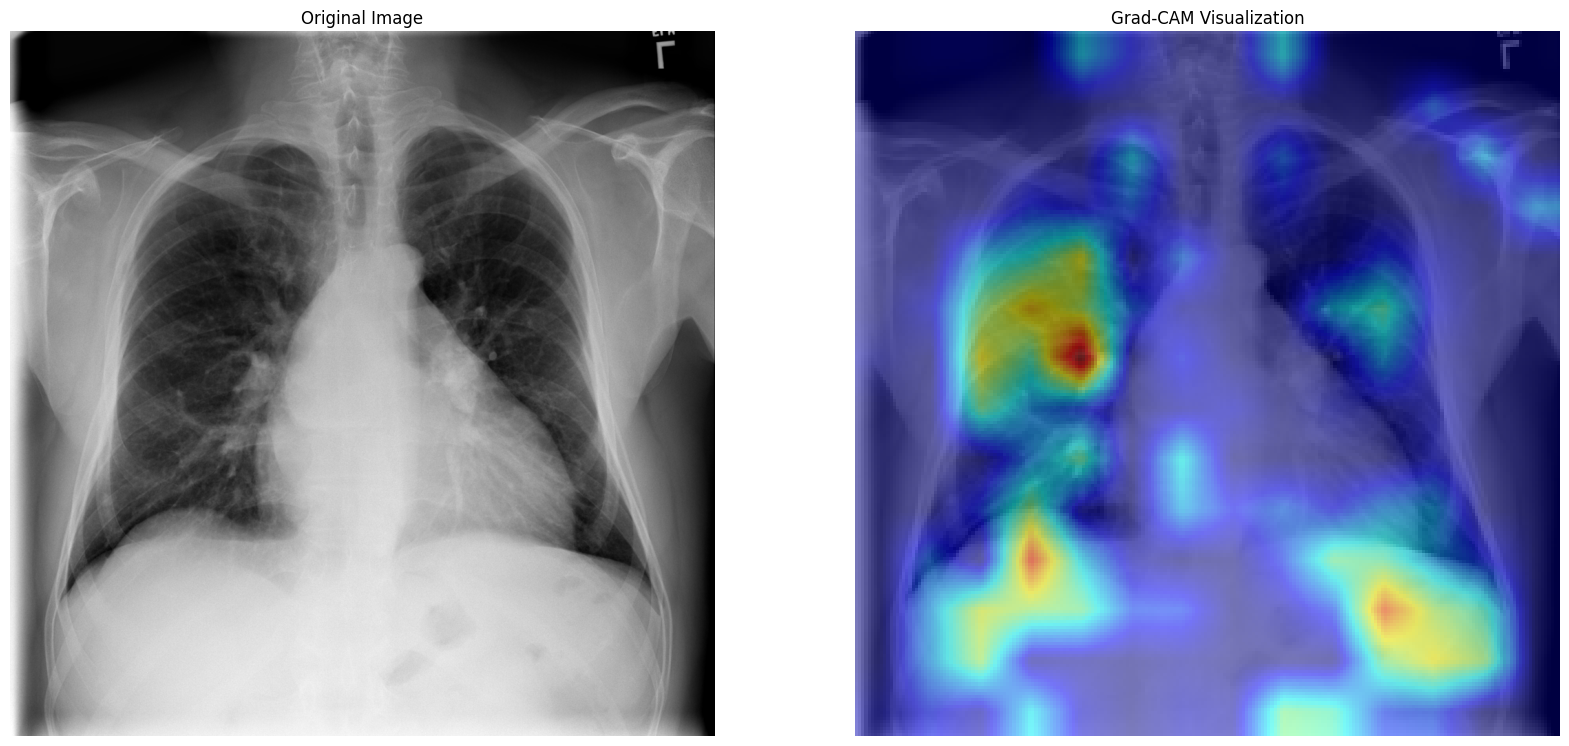

In [13]:
for label in label_columns:
    print(f"Generating Grad-CAM for {label}...")
    target_idx = label_columns.index(label)
    targets = [ClassifierOutputTarget(target_idx)]
    _, gradcam_image = get_vit_visualization(model, processor, image_path, target_layers, targets)
    plot_image_with_gradcam(image, gradcam_image)

In [14]:
def vit_inference(model, processor, image_path):
    label_columns = ['Cardiomegaly', 'Edema', 'Consolidation', 'Pneumonia', 'No Finding']

    image = Image.open(image_path)

    if image.mode != 'RGB':
        image = image.convert('RGB')

    inputs = processor(images=image, return_tensors="pt")

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    predicted_class_idx = torch.argmax(logits, dim=-1).item()  # Get the class index

    predicted_class_label = label_columns[predicted_class_idx]

    return predicted_class_label, predicted_class_idx



In [15]:
dataset = catalog.load("cxr8_metadata")

[05/04/26 13:13:31] INFO     Loading data from cxr8_metadata (CSVDataset)...                   ]8;id=117628;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=88180;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\io\data_catalog.py#1048\1048]8;;\

In [16]:
label_columns = ['Cardiomegaly', 'Edema', 'Consolidation', 'Pneumonia', 'No Finding']
filtered_dataset = dataset[dataset['finding_labels'].str.split(',').apply(lambda x: any(label in x for label in label_columns))]


In [17]:
print(f"Total samples in original dataset: {len(dataset)}")
print(f"Total samples in filtered dataset: {len(filtered_dataset)}")
filtered_dataset.head()

Total samples in original dataset: 112120
Total samples in filtered dataset: 63714


,image_index,finding_labels,follow-up #,patient_id,patient_age,patient_sex,view_position,original_image_width,original_image_height,original_image_pixel_spacing_x,original_image_pixel_spacing_y
0,00000001_000.png,Cardiomegaly,0,1,57,M,PA,2682,2749,0.143,0.143
3,00000002_000.png,No Finding,0,2,80,M,PA,2500,2048,0.171,0.171
13,00000005_000.png,No Finding,0,5,69,F,PA,2048,2500,0.168,0.168
14,00000005_001.png,No Finding,1,5,69,F,AP,2500,2048,0.168,0.168
15,00000005_002.png,No Finding,2,5,69,F,AP,2500,2048,0.168,0.168


In [18]:
filtered_dataset['finding_labels'].value_counts()


finding_labels
No Finding       60361
Consolidation     1310
Cardiomegaly      1093
Edema              628
Pneumonia          322
Name: count, dtype: int64

#### Testing model on only images with diseases (only 4 diseases which model knows)

In [ ]:
total_labels = []
correctly_predicted_labels = []

for idx, row in tqdm(enumerate(filtered_dataset.itertuples()), total=len(filtered_dataset)):
    if row.finding_labels == "No Finding":
        continue
    image_path = os.path.join("data/01_raw/images", row.image_index)
    predicted_label, predicted_idx = vit_inference(hf_model, processor, image_path)
    total_labels.append(row.finding_labels)
    correctly_predicted_labels.append(predicted_label == row.finding_labels)

print(f"Total samples: {len(total_labels)}")
print(f"Correctly predicted samples: {sum(correctly_predicted_labels)}")
print(f"Accuracy: {sum(correctly_predicted_labels) / len(total_labels) * 100:.2f}%")


  0%|          | 0/63714 [00:00<?, ?it/s]

100%|██████████| 63714/63714 [26:37<00:00, 39.87it/s]  

Total samples: 3353
Correctly predicted samples: 875
Accuracy: 26.10%


### AttentionRollout - model : facebookresearch/deit:main

Code in cell below comes from : "https://github.com/jacobgil/vit-explain/blob/main/vit_grad_rollout.py"

In [19]:
def grad_rollout_fn(attentions, gradients, discard_ratio):
    result = torch.eye(attentions[0].size(-1))
    with torch.no_grad():
        for attention, grad in zip(attentions, gradients):
            weights = grad
            attention_heads_fused = (attention*weights).mean(axis=1)
            attention_heads_fused[attention_heads_fused < 0] = 0

            # Drop the lowest attentions, but
            # don't drop the class token
            flat = attention_heads_fused.view(attention_heads_fused.size(0), -1)
            _, indices = flat.topk(int(flat.size(-1)*discard_ratio), -1, False)
            #indices = indices[indices != 0]
            flat[0, indices] = 0

            I = torch.eye(attention_heads_fused.size(-1))
            a = (attention_heads_fused + 1.0*I)/2
            a = a / a.sum(dim=-1)
            result = torch.matmul(a, result)

    # Look at the total attention between the class token,
    # and the image patches
    mask = result[0, 0 , 1 :]
    # In case of 224x224 image, this brings us from 196 to 14
    width = int(mask.size(-1)**0.5)
    mask = mask.reshape(width, width).numpy()
    mask = mask / np.max(mask)
    return mask

class VITAttentionGradRollout:
    def __init__(self, model, attention_layer_name='attn_drop',
        discard_ratio=0.9):
        self.model = model
        self.discard_ratio = discard_ratio
        for name, module in self.model.named_modules():
            if attention_layer_name in name:
                module.register_forward_hook(self.get_attention)
                module.register_backward_hook(self.get_attention_gradient)

        self.attentions = []
        self.attention_gradients = []

    def get_attention(self, module, input, output):
        self.attentions.append(output.cpu())

    def get_attention_gradient(self, module, grad_input, grad_output):
        self.attention_gradients.append(grad_input[0].cpu())

    def __call__(self, input_tensor, category_index):
        self.model.zero_grad()
        output = self.model(input_tensor)
        category_mask = torch.zeros(output.size())
        category_mask[:, category_index] = 1
        loss = (output*category_mask).sum()
        loss.backward()

        return grad_rollout_fn(self.attentions, self.attention_gradients,
            self.discard_ratio)

In [27]:
model = torch.hub.load('facebookresearch/deit:main',
'deit_tiny_patch16_224', pretrained=True)
model.eval()

for block in model.blocks:
    block.attn.fused_attn = False

image_path = Path("data/01_raw/images/00000001_000.png")
image = Image.open(image_path).convert("RGB")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

input_tensor = transform(image).unsqueeze(0)

grad_rollout_runner = VITAttentionGradRollout(model, discard_ratio=0.9)
mask = grad_rollout_runner(input_tensor, category_index=0)

mask_upsampled = cv2.resize(mask, (224, 224), interpolation=cv2.INTER_CUBIC)

Using cache found in C:\Users\barte/.cache\torch\hub\facebookresearch_deit_main


### Cocnlusions
The model used for attentionrollout has 1000 different classes hat are not connected with RTG images. That's why I wouldn't consider images below as helpfull

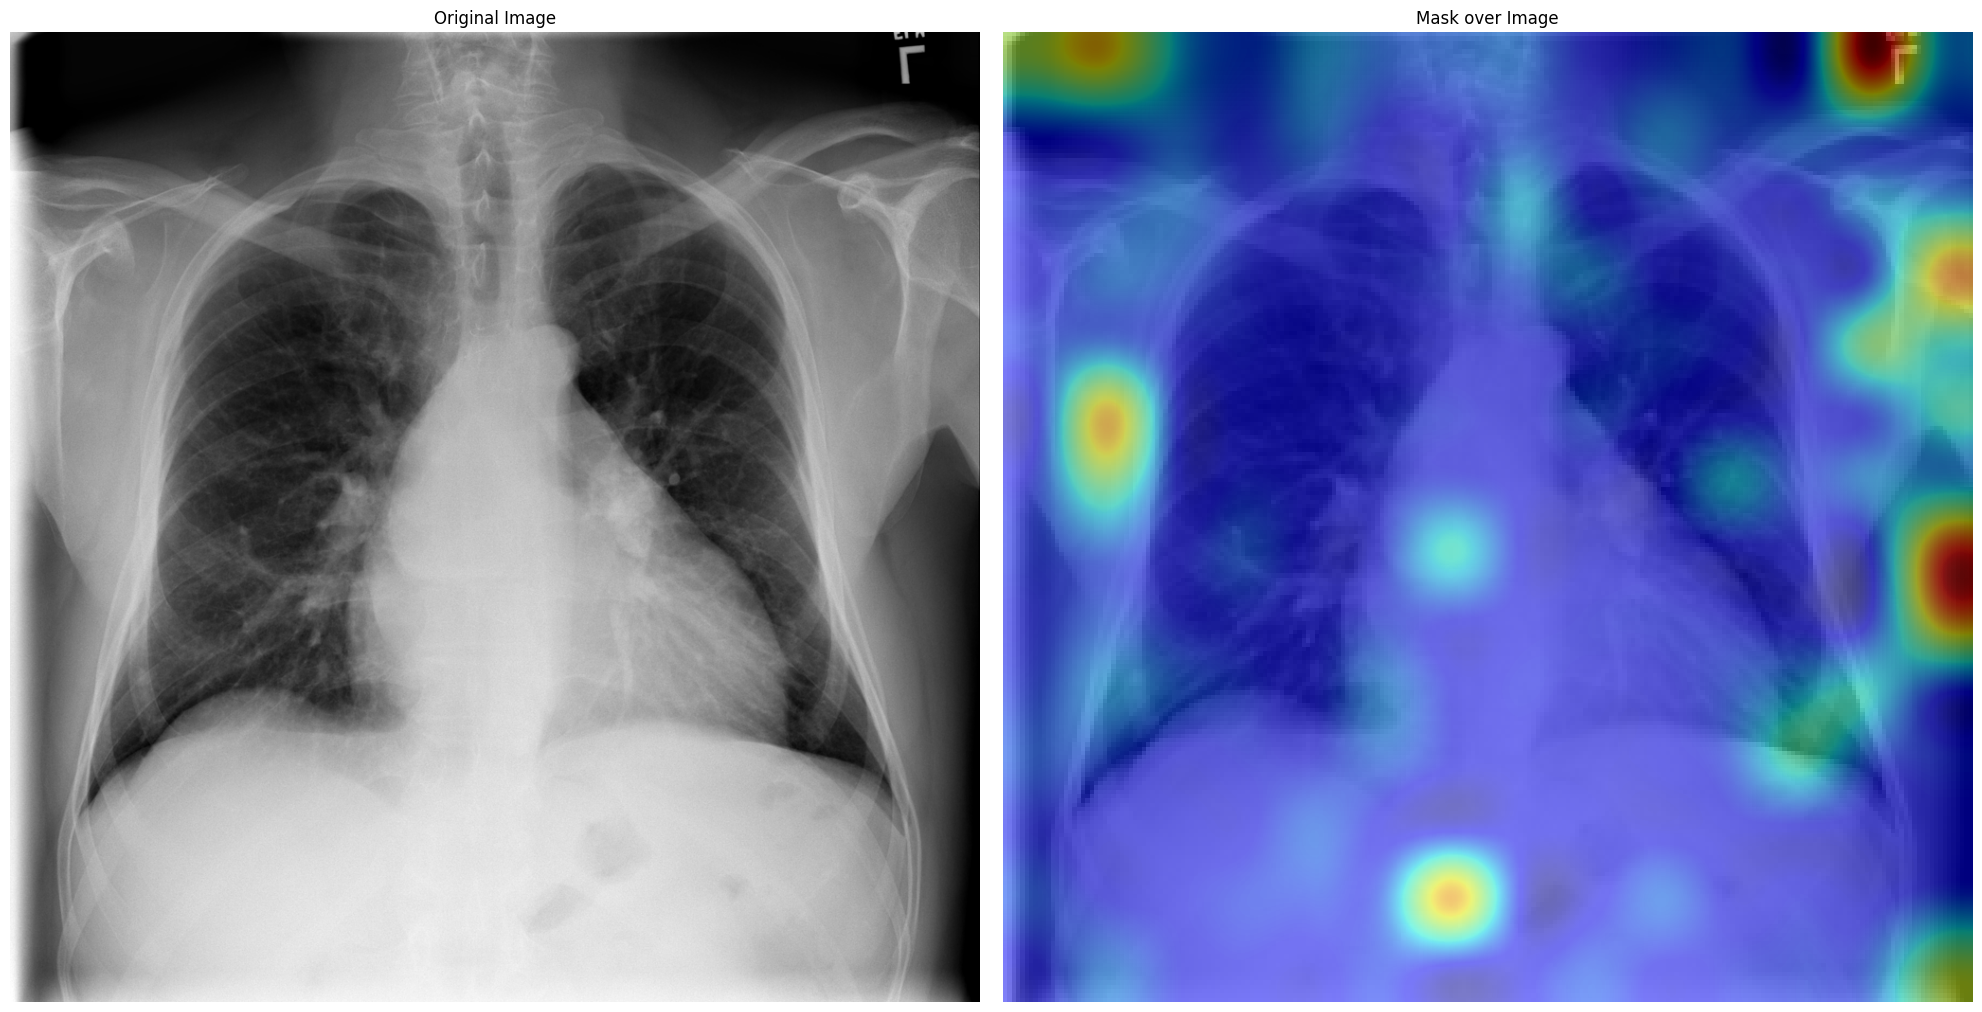

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(image)
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(image.resize((224, 224)))
ax[1].imshow(mask_upsampled, cmap="jet", alpha=0.5, interpolation="bilinear")
ax[1].set_title("Mask over Image")
ax[1].axis("off")

plt.tight_layout()
plt.show()